# 07 — Modeliranje i evaluacija

U ovom notebook-u koristimo pripremljene podatke iz prethodnih faza
projekta za izgradnju i evaluaciju modela mašinskog učenja.

Cilj je da napravimo modele koji mogu da predvide da li će korisnik
napustiti kompaniju (`Churn`) na osnovu njegovih karakteristika i
korišćenih usluga.

Koristićemo više algoritama kako bismo mogli da ih međusobno uporedimo:

- **Logistička regresija** — jednostavan i interpretabilan linearni model
- **Random Forest** — ansambl više stabala odlučivanja
- **XGBoost** — napredni ansambl model zasnovan na gradijentnom boostingu

Za evaluaciju nećemo koristiti samo accuracy, već više metrika:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Posebnu pažnju posvećujemo **Recall** i **F1-score** jer je ciljna
promenljiva `Churn` nebalansirana.

## 1. Učitavanje pripremljenih podataka

Učitavamo podatke koji su pripremljeni u notebook-u `05`.

Za modeliranje koristimo podatke iz foldera `data/ml/`, koji su već:

- očišćeni,
- transformisani,
- enkodirani,
- potpuno numerički.

Koristimo odvojene trening i test skupove. Model će biti treniran
isključivo na trening skupu, dok ćemo test skup koristiti tek za konačnu
evaluaciju performansi.

In [30]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

putanja_ml = "../data/ml/"

X_train = pd.read_csv(putanja_ml + "X_train.csv")
X_test = pd.read_csv(putanja_ml + "X_test.csv")
y_train = pd.read_csv(putanja_ml + "y_train.csv").squeeze()
y_test = pd.read_csv(putanja_ml + "y_test.csv").squeeze()

print("Podaci uspešno učitani:")
print(f"X_train: {X_train.shape[0]} redova × {X_train.shape[1]} kolona")
print(f"X_test:  {X_test.shape[0]} redova × {X_test.shape[1]} kolona")
print(f"y_train: {y_train.shape[0]} vrednosti")
print(f"y_test:  {y_test.shape[0]} vrednosti")

Podaci uspešno učitani:
X_train: 5625 redova × 24 kolona
X_test:  1407 redova × 24 kolona
y_train: 5625 vrednosti
y_test:  1407 vrednosti


### 1.1 Provera strukture podataka

Pre treniranja modela proveravamo da li su trening i test skup pravilno
učitani i da li imaju isti broj prediktora.

In [31]:
print("Broj kolona:")
print(f"X_train: {X_train.shape[1]}")
print(f"X_test:  {X_test.shape[1]}")

print("\nRaspodela ciljnih klasa:")
print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nNedostajuće vrednosti:")
print(f"X_train NaN: {X_train.isnull().sum().sum()}")
print(f"X_test NaN:  {X_test.isnull().sum().sum()}")
print(f"y_train NaN: {y_train.isnull().sum()}")
print(f"y_test NaN:  {y_test.isnull().sum()}")

Broj kolona:
X_train: 24
X_test:  24

Raspodela ciljnih klasa:
y_train:
Churn
0    4130
1    1495
Name: count, dtype: int64

y_test:
Churn
0    1033
1     374
Name: count, dtype: int64

Nedostajuće vrednosti:
X_train NaN: 0
X_test NaN:  0
y_train NaN: 0
y_test NaN:  0


## 2. Logistička regresija

Logistička regresija je osnovni model za rešavanje problema binarne
klasifikacije. U našem slučaju koristi se za predviđanje da li će korisnik
napustiti kompaniju (`Churn = 1`) ili ostati (`Churn = 0`).

Model je jednostavan i lako interpretabilan, pa predstavlja dobru početnu
tačku za poređenje sa složenijim modelima.

Pošto je ciljna promenljiva nebalansirana, koristimo
`class_weight="balanced"` kako bismo modelu dali veću težinu manjinskoj
klasi (`Churn = 1`).

### 2.1 Definisanje modela

Logistička regresija je osnovni model za rešavanje problema binarne
klasifikacije. U našem slučaju koristi se za predviđanje da li će korisnik
napustiti kompaniju (`Churn = 1`) ili ostati (`Churn = 0`).

Pošto promenljive imaju različite opsege vrednosti, pre treniranja
standardizujemo numeričke karakteristike. Standardizacija omogućava
logističkoj regresiji da efikasnije pronađe optimalne parametre i
poboljšava konvergenciju algoritma.

Pošto su klase nebalansirane, koristimo `class_weight="balanced"` kako bi
model dao veću težinu manjinskoj klasi (`Churn = 1`).

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardizacija karakteristika.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definisanje logističke regresije.
model_logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Logistička regresija je uspešno definisana.")

Logistička regresija je uspešno definisana.


### 2.2 Treniranje modela

Model treniramo isključivo na trening skupu (`X_train` i `y_train`).
Test skup se u ovoj fazi ne koristi, kako bi ostao nezavisan za konačnu
evaluaciju modela.

Tokom treniranja model uči odnos između karakteristika korisnika i ciljne
promenljive `Churn`.

In [33]:
model_logreg.fit(X_train_scaled, y_train)

print("Logistička regresija je uspešno istrenirana.")

Logistička regresija je uspešno istrenirana.


### 2.3 Predikcija

Nakon treniranja, model koristi karakteristike korisnika iz test skupa
(`X_test`) kako bi predvideo njihovu pripadnost jednoj od dve klase:

- `0` — korisnik ostaje
- `1` — korisnik napušta kompaniju

Test skup se koristi prvi put nakon treniranja modela, čime dobijamo
nezavisne predikcije za kasniju evaluaciju.

In [34]:
y_pred_logreg = model_logreg.predict(X_test_scaled)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_logreg)}")

Predikcija završena.
Broj predikcija: 1407


### 2.4 Raspodela predviđenih klasa

Proveravamo koliko je korisnika model svrstao u klasu `0` i koliko u klasu
`1`. Ovu raspodelu možemo uporediti sa stvarnom raspodelom ciljnih klasa
u test skupu.

In [35]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_logreg).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    803
1    604
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 2.5 Evaluacija logističke regresije

Nakon treniranja i predikcije, procenjujemo kvalitet modela pomoću nekoliko
metrika.

Koristimo:

- **Accuracy** — procenat svih tačno klasifikovanih korisnika
- **Precision** — od svih korisnika koje je model označio kao one koji će
  otići, koliko ih zaista odlazi
- **Recall** — od svih korisnika koji su zaista otišli, koliko je model
  uspešno prepoznao
- **F1-score** — harmonijska sredina Precision i Recall metrike
- **ROC-AUC** — meri koliko dobro model razlikuje korisnike koji odlaze od
  korisnika koji ostaju

Kod problema predviđanja churn-a posebno nam je važan **Recall za klasu 1**,
jer želimo da prepoznamo što veći broj korisnika koji će napustiti kompaniju.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

# Verovatnoća pripadnosti klasi 1.
y_prob_logreg = model_logreg.predict_proba(X_test_scaled)[:, 1]

roc_auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("=" * 50)
print("EVALUACIJA LOGISTIČKE REGRESIJE")
print("=" * 50)
print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall:    {recall_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")
print(f"ROC-AUC:   {roc_auc_logreg:.4f}")

EVALUACIJA LOGISTIČKE REGRESIJE
Accuracy:  0.7242
Precision: 0.4884
Recall:    0.7888
F1-score:  0.6033
ROC-AUC:   0.8342


### 2.6 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika.

Kod našeg problema imamo četiri slučaja:

- **True Negative (TN)** — korisnik je ostao i model je to pravilno predvideo
- **False Positive (FP)** — korisnik je ostao, ali je model predvideo da će
  otići
- **False Negative (FN)** — korisnik je otišao, ali model to nije prepoznao
- **True Positive (TP)** — korisnik je otišao i model je to pravilno
  predvideo

Posebno je važan broj **False Negative** slučajeva, jer oni predstavljaju
korisnike koji će otići, a model ih nije prepoznao.

Matrica konfuzije:
[[724 309]
 [ 79 295]]


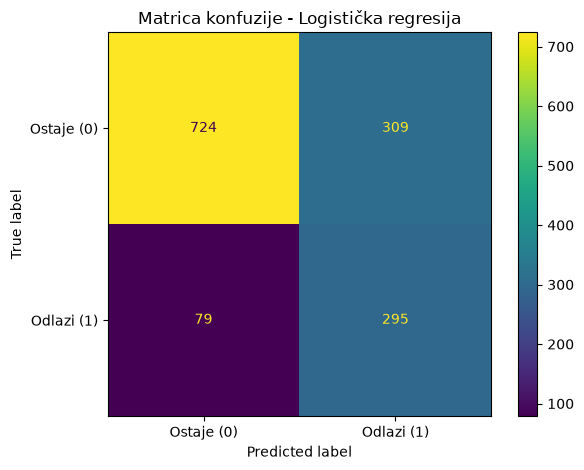

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("Matrica konfuzije:")
print(cm_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - Logistička regresija")
plt.tight_layout()

plt.savefig(
    "../images/07_logreg_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

Matrica konfuzije pokazuje da je logistička regresija uspešno prepoznala
većinu korisnika koji su zaista napustili kompaniju (**295 TP**), dok je
propustila **79 korisnika (FN)** koji su stvarno otišli.

Sa druge strane, model je **309 korisnika (FP)** označio kao potencijalne
odlaske iako su oni ostali. Ovakav rezultat je očekivan zbog korišćenja
`class_weight="balanced"`, kojim smo povećali osetljivost modela na
manjinsku klasu `Churn = 1`.

Ukupno, logistička regresija pokazuje dobru sposobnost prepoznavanja
korisnika koji odlaze, što potvrđuje i Recall od **78.88%**, ali uz nešto
veći broj lažno pozitivnih predikcija.

## 3. Random Forest

Random Forest je ansambl metoda koja kombinuje veliki broj stabala odluke.
Svako stablo pravi svoje predikcije, a konačna klasifikacija dobija se
kombinovanjem njihovih rezultata.

Za razliku od logističke regresije, Random Forest može da modeluje složene
i nelinearne odnose između atributa. To je posebno korisno kada uticaj
atributa na `Churn` nije jednostavan i linearan.

Kao i kod logističke regresije, koristimo `class_weight="balanced"` kako
bismo uzeli u obzir nebalansirane klase.

### 3.1 Definisanje modela

In [38]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest je uspešno definisan.")

Random Forest je uspešno definisan.


### 3.2 Treniranje modela

Random Forest treniramo na trening skupu. Test skup ostaje odvojen i
koristiće se tek nakon završetka treniranja za evaluaciju modela.

In [39]:
model_rf.fit(X_train, y_train)

print("Random Forest je uspešno istreniran.")

Random Forest je uspešno istreniran.


### 3.3 Predikcija

Nakon treniranja, Random Forest predviđa klasu za svakog korisnika iz
test skupa.

In [40]:
y_pred_rf = model_rf.predict(X_test)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_rf)}")

Predikcija završena.
Broj predikcija: 1407


### 3.4 Raspodela predviđenih klasa

Proveravamo raspodelu klasa koje je Random Forest predvideo i upoređujemo
je sa stvarnom raspodelom klasa u test skupu.

In [41]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_rf).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    964
1    443
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 3.5 Evaluacija Random Forest-a

Random Forest evaluiramo pomoću istih metrika koje smo koristili za
logističku regresiju kako bi poređenje modela bilo ravnopravno.

Koristimo Accuracy, Precision, Recall, F1-score i ROC-AUC.
Posebnu pažnju posvećujemo Recall-u i F1-score-u zbog nebalansiranih klasa.

In [42]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Verovatnoća pripadnosti klasi 1.
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 50)
print("EVALUACIJA RANDOM FOREST-A")
print("=" * 50)
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

EVALUACIJA RANDOM FOREST-A
Accuracy:  0.7719
Precision: 0.5598
Recall:    0.6631
F1-score:  0.6071
ROC-AUC:   0.8215


### 3.4 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika
za Random Forest model.

Posebno pratimo **False Negative (FN)** slučajeve, odnosno korisnike koji
su zaista napustili kompaniju, ali ih model nije prepoznao.

Kod problema churn-a cilj je da broj ovakvih slučajeva bude što manji.

Matrica konfuzije:
[[838 195]
 [126 248]]


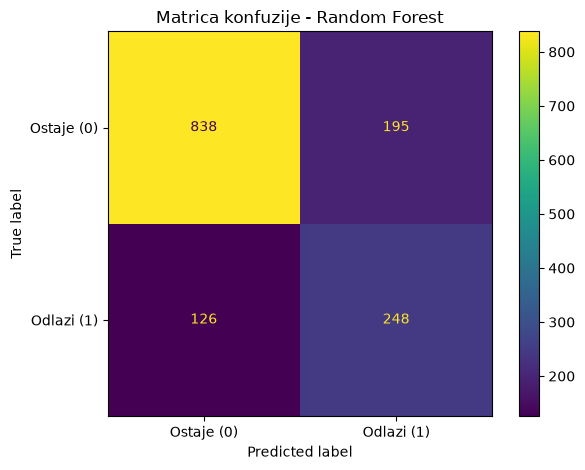

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Matrica konfuzije:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - Random Forest")
plt.tight_layout()

plt.savefig(
    "../images/07_rf_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

Matrica konfuzije pokazuje da je Random Forest pravilno prepoznao
**248 korisnika koji su zaista napustili kompaniju (TP)**, dok je
**126 korisnika koji su otišli ostalo neprepoznato (FN)**.

Model je **195 korisnika (FP)** označio kao potencijalne odlaske iako su
oni zapravo ostali.

U poređenju sa logističkom regresijom, Random Forest ima veći broj
korisnika koje je pravilno klasifikovao kao one koji ostaju, ali je
propustio više stvarnih odlazaka. To je u skladu sa nižim Recall-om
Random Forest modela (**66.31%**) u odnosu na logističku regresiju
(**78.88%**).

Iako Random Forest ima veću Accuracy vrednost, logistička regresija je
u ovom slučaju uspešnija u prepoznavanju korisnika koji će napustiti
kompaniju, što je posebno važno za problem churn-a.

## 4. XGBoost

XGBoost (Extreme Gradient Boosting) je napredni ansambl algoritam koji
gradi niz stabala odlučivanja tako što svako naredno stablo pokušava da
ispravi greške prethodnih stabala.

Za razliku od Random Forest-a, gde se stabla uglavnom grade nezavisno,
XGBoost ih gradi sekvencijalno i postepeno poboljšava model.

XGBoost može da modeluje složene i nelinearne odnose između atributa i
ciljne promenljive, pa ga koristimo kao treći model i upoređujemo njegove
performanse sa logističkom regresijom i Random Forest-om.

Pošto je ciljna promenljiva nebalansirana, podešavamo težinu pozitivne
klase (`Churn = 1`) pomoću parametra `scale_pos_weight`.

### 4.1 Definisanje modela

Za XGBoost koristimo nekoliko osnovnih parametara koji kontrolišu
složenost i proces učenja modela.

`n_estimators` određuje broj stabala, `max_depth` maksimalnu dubinu
stabala, dok `learning_rate` određuje koliko snažno svako novo stablo
utiče na konačni model.

Parametar `scale_pos_weight` koristimo zbog nebalansiranih klasa.

In [44]:
from xgboost import XGBClassifier

# Izračunavanje težine pozitivne klase.
broj_0 = (y_train == 0).sum()
broj_1 = (y_train == 1).sum()

scale_pos_weight = broj_0 / broj_1

print(f"Broj korisnika koji ostaju (0): {broj_0}")
print(f"Broj korisnika koji odlaze (1): {broj_1}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

print("\nXGBoost je uspešno definisan.")

Broj korisnika koji ostaju (0): 4130
Broj korisnika koji odlaze (1): 1495
scale_pos_weight: 2.76

XGBoost je uspešno definisan.


### 4.2 Treniranje modela

XGBoost treniramo isključivo na trening skupu. Test skup se ne koristi
tokom procesa učenja, već ostaje nezavisan za kasniju evaluaciju.

In [45]:
model_xgb.fit(X_train, y_train)

print("XGBoost je uspešno istreniran.")

XGBoost je uspešno istreniran.


### 4.3 Predikcija

Nakon treniranja, XGBoost koristi karakteristike korisnika iz test skupa
kako bi predvideo da li korisnik ostaje (`0`) ili napušta kompaniju (`1`).

In [46]:
y_pred_xgb = model_xgb.predict(X_test)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_xgb)}")

Predikcija završena.
Broj predikcija: 1407


### 4.4 Raspodela predviđenih klasa

Proveravamo raspodelu predviđenih klasa i upoređujemo je sa stvarnom
raspodelom korisnika u test skupu.

In [47]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_xgb).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    832
1    575
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 4.5 Evaluacija XGBoost-a

Nakon treniranja i predikcije procenjujemo kvalitet XGBoost modela pomoću
istih metrika koje smo koristili za prethodne modele:

- **Accuracy** — procenat tačno klasifikovanih korisnika
- **Precision** — koliko je predviđenih odlazaka zaista bilo odlazak
- **Recall** — koliko je stvarnih odlazaka model uspešno prepoznao
- **F1-score** — ravnoteža između Precision i Recall metrike
- **ROC-AUC** — sposobnost modela da razlikuje korisnike koji odlaze od
  korisnika koji ostaju

Posebno pratimo Recall, jer je za poslovni problem churn-a važno da
prepoznamo što veći broj korisnika koji će napustiti kompaniju.

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Verovatnoća pripadnosti klasi 1.
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print("EVALUACIJA XGBOOST-A")
print("=" * 50)
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

EVALUACIJA XGBOOST-A
Accuracy:  0.7392
Precision: 0.5061
Recall:    0.7781
F1-score:  0.6133
ROC-AUC:   0.8301


### 4.6 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika
za XGBoost model.

Posebno pratimo **False Negative (FN)** slučajeve, odnosno korisnike koji
su zaista napustili kompaniju, ali ih model nije prepoznao.

Kod problema churn-a cilj je da broj ovakvih slučajeva bude što manji.

Matrica konfuzije:
[[749 284]
 [ 83 291]]


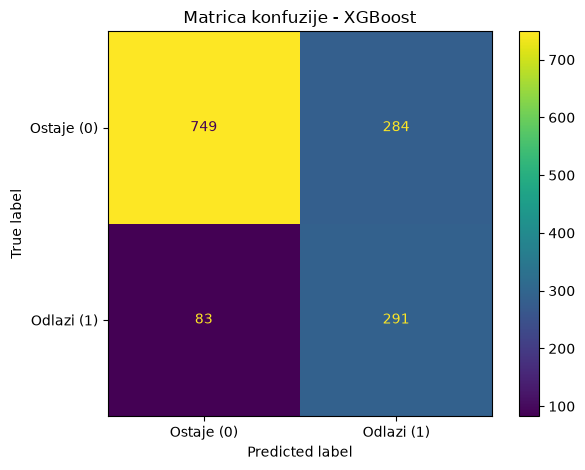

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Matrica konfuzije:")
print(cm_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - XGBoost")
plt.tight_layout()

plt.savefig(
    "../images/07_xgb_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

Matrica konfuzije pokazuje da je XGBoost pravilno prepoznao
**291 korisnika koji su zaista napustili kompaniju (TP)**, dok je
**83 korisnika koji su otišli ostalo neprepoznato (FN)**.

Sa druge strane, model je **284 korisnika (FP)** označio kao potencijalne
odlaske iako su oni zapravo ostali, dok je **749 korisnika (TN)** pravilno
prepoznao kao korisnike koji ostaju.

Za problem churn-a posebno je važan broj **False Negative** slučajeva,
jer oni predstavljaju korisnike koji će otići, a model ih nije
identifikovao na vreme. XGBoost je ostvario **Recall od 77.81%**, što znači
da je uspešno prepoznao veliki deo korisnika koji su zaista napustili
kompaniju.

Iako model pravi određeni broj lažno pozitivnih predikcija, ovakav
rezultat može biti prihvatljiv u poslovnom kontekstu jer je korisnije
identifikovati potencijalnog korisnika koji odlazi čak i kada se ispostavi
da bi on ostao, nego propustiti korisnika koji će zaista napustiti
kompaniju.

## 5. Poređenje modela

Nakon treniranja i evaluacije sva tri modela, upoređujemo njihove
performanse pomoću istih metrika.

Cilj poređenja nije da se model izabere samo na osnovu Accuracy metrike,
već da se uzmu u obzir sve relevantne metrike. Za naš problem posebno
obraćamo pažnju na Recall, jer je važno da model prepozna što veći broj
korisnika koji će napustiti kompaniju.

In [50]:
# Kreiramo tabelu sa rezultatima sva tri modela.

rezultati_modela = pd.DataFrame({
    "Model": [
        "Logistička regresija",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_logreg,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_logreg,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_logreg,
        recall_rf,
        recall_xgb
    ],
    "F1-score": [
        f1_logreg,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_logreg,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

# Zaokružujemo rezultate na 4 decimale.
rezultati_modela = rezultati_modela.round(4)

print("POREĐENJE MODELA")
print("=" * 80)

display(rezultati_modela)

POREĐENJE MODELA


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistička regresija,0.7242,0.4884,0.7888,0.6033,0.8342
1,Random Forest,0.7719,0.5598,0.6631,0.6071,0.8215
2,XGBoost,0.7392,0.5061,0.7781,0.6133,0.8301


### 5.2 Grafičko poređenje modela

Pored tabelarnog prikaza, performanse modela prikazujemo i grafički kako
bismo lakše uočili razlike između modela.

Upoređujemo Accuracy, Precision, Recall, F1-score i ROC-AUC metrike.

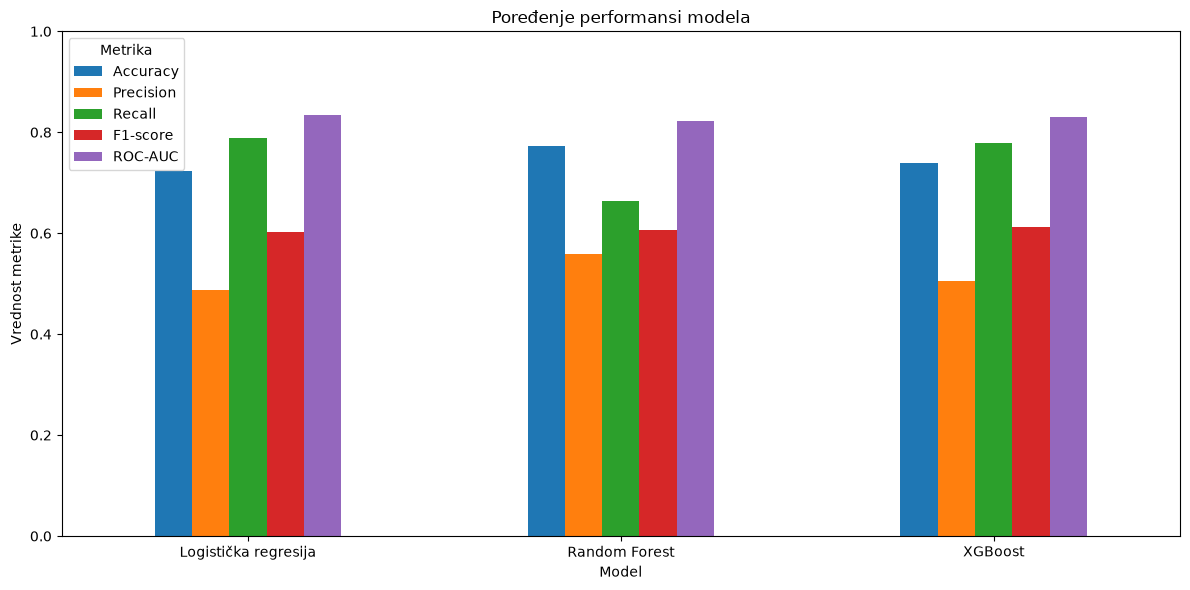

In [51]:
import matplotlib.pyplot as plt

metrike = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

rezultati_modela.set_index("Model")[metrike].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Poređenje performansi modela")
plt.xlabel("Model")
plt.ylabel("Vrednost metrike")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrika")
plt.tight_layout()

plt.savefig(
    "../images/07_model_comparison.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### 5.3 Izbor najboljeg modela

Prilikom izbora konačnog modela uzimamo u obzir sve evaluacione metrike,
ali posebnu pažnju posvećujemo **Recall** i **F1-score**.

Recall je važan jer želimo da identifikujemo što veći broj korisnika koji
će napustiti kompaniju. F1-score predstavlja ravnotežu između Recall i
Precision metrike.

Na osnovu dobijenih rezultata, XGBoost ostvaruje najbolji F1-score
(**0.6133**), dok logistička regresija ostvaruje najbolji Recall
(**0.7888**) i ROC-AUC (**0.8342**).

Random Forest ostvaruje najbolji Accuracy (**0.7719**) i Precision
(**0.5598**), ali ima najniži Recall (**0.6631**).

Zbog toga se ne može reći da jedan model dominira u svim aspektima.
Izbor modela zavisi od toga koja metrika je najvažnija za konkretnu
primenu.

Za naš problem, gde je posebno važno prepoznati korisnike koji će
napustiti kompaniju, **logistička regresija predstavlja vrlo dobar izbor
zbog najvišeg Recall-a i ROC-AUC-a**. XGBoost je takođe veoma konkurentan,
jer ostvaruje najbolji F1-score.

## 6. Analiza važnosti atributa (Feature Importance)

Pored evaluacionih metrika, važno je razumeti **koji atributi najviše
doprinose predikciji**. Ovo nam služi za dve stvari:

1. **Interpretabilnost** — možemo objasniti poslovnim korisnicima zašto
   model predviđa da će neki korisnik otići.
2. **Provera feature engineering-a** — proveravamo da li su nove
   promenljive koje smo napravili u svesci `05` (`ActiveServices`,
   `TenureGroup`) zaista korisne modelu, ili su suvišne.

Za **Logističku regresiju** posmatramo koeficijente (predznak pokazuje
smer uticaja, veličina jačinu). Za **Random Forest** i **XGBoost**
koristimo ugrađenu meru `feature_importances_`.

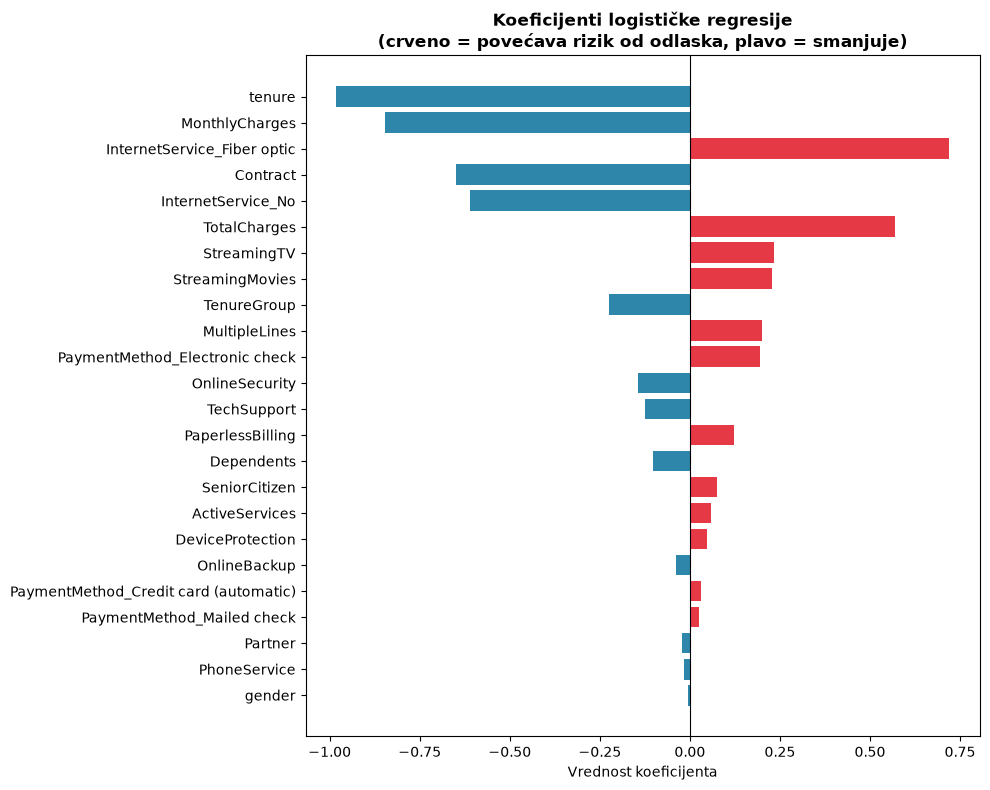

Top 5 atributa koji NAJVIŠE POVEĆAVAJU rizik od odlaska:
InternetService_Fiber optic    0.720279
TotalCharges                   0.568154
StreamingTV                    0.233508
StreamingMovies                0.227818
MultipleLines                  0.199327
dtype: float64

Top 5 atributa koji NAJVIŠE SMANJUJU rizik od odlaska:
tenure               -0.981802
MonthlyCharges       -0.846516
Contract             -0.649496
InternetService_No   -0.611559
TenureGroup          -0.224809
dtype: float64


In [52]:
import numpy as np

koef_logreg = pd.Series(model_logreg.coef_[0], index=X_train.columns)
koef_logreg_sorted = koef_logreg.reindex(koef_logreg.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
colors_bar = ["#E63946" if v > 0 else "#2E86AB" for v in koef_logreg_sorted]
plt.barh(koef_logreg_sorted.index[::-1], koef_logreg_sorted.values[::-1], color=colors_bar[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Koeficijenti logističke regresije\n(crveno = povećava rizik od odlaska, plavo = smanjuje)", fontweight="bold")
plt.xlabel("Vrednost koeficijenta")
plt.tight_layout()
plt.savefig("../images/07_logreg_coefficients.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 atributa koji NAJVIŠE POVEĆAVAJU rizik od odlaska:")
print(koef_logreg.sort_values(ascending=False).head(5))
print("\nTop 5 atributa koji NAJVIŠE SMANJUJU rizik od odlaska:")
print(koef_logreg.sort_values().head(5))

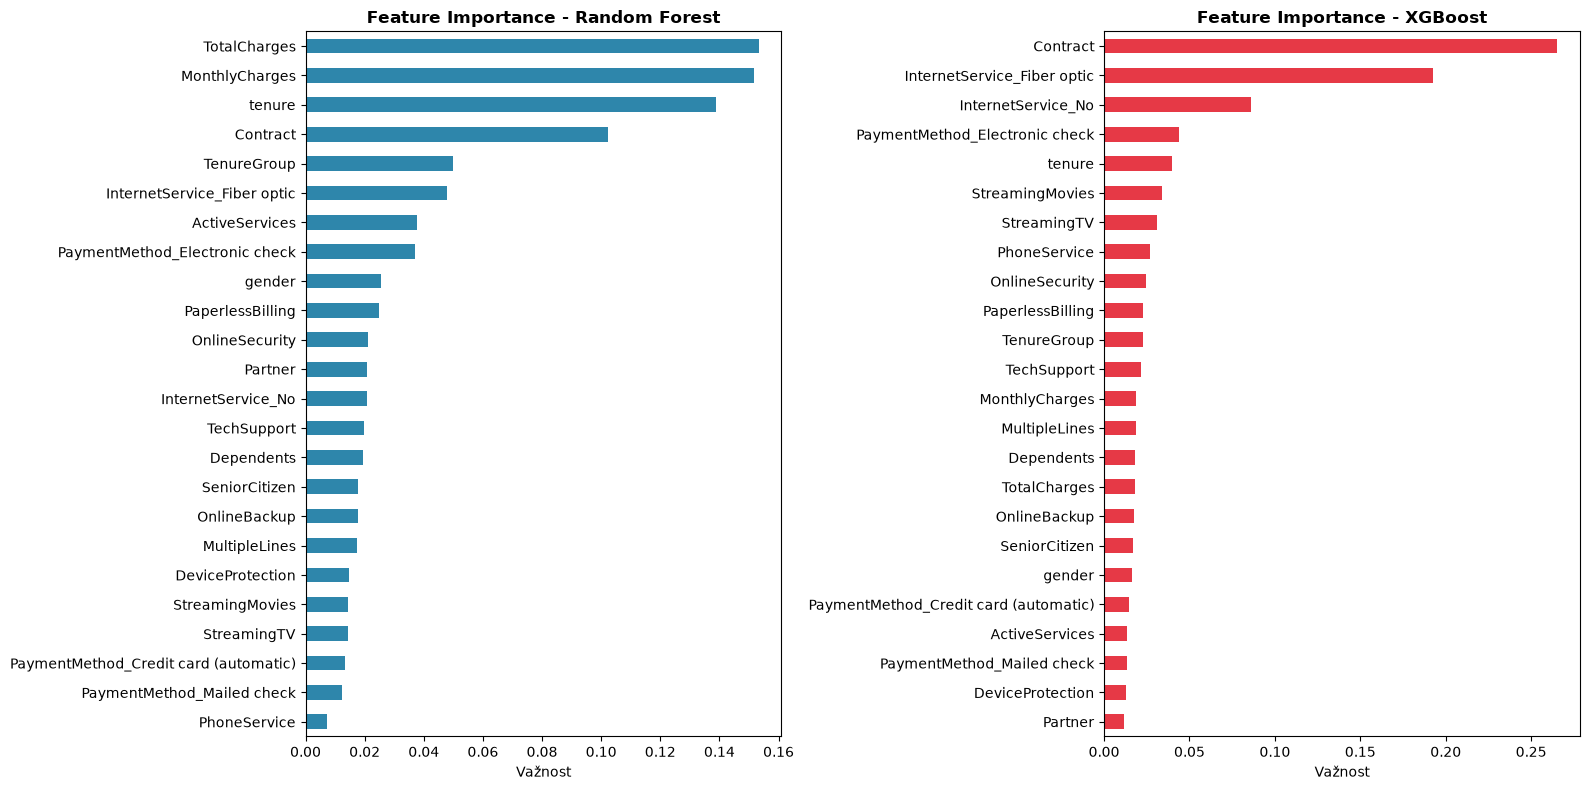

Top 5 najvažnijih atributa - Random Forest:
TotalCharges      0.153321
MonthlyCharges    0.151618
tenure            0.138996
Contract          0.102336
TenureGroup       0.049920
dtype: float64

Top 5 najvažnijih atributa - XGBoost:
Contract                          0.265308
InternetService_Fiber optic       0.192599
InternetService_No                0.085996
PaymentMethod_Electronic check    0.043767
tenure                            0.039555
dtype: float32


In [53]:
importance_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importance_xgb = pd.Series(model_xgb.feature_importances_, index=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

importance_rf.sort_values().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Feature Importance - Random Forest", fontweight="bold")
axes[0].set_xlabel("Važnost")

importance_xgb.sort_values().plot(kind="barh", ax=axes[1], color="#E63946")
axes[1].set_title("Feature Importance - XGBoost", fontweight="bold")
axes[1].set_xlabel("Važnost")

plt.tight_layout()
plt.savefig("../images/07_feature_importance_rf_xgb.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 najvažnijih atributa - Random Forest:")
print(importance_rf.sort_values(ascending=False).head(5))
print("\nTop 5 najvažnijih atributa - XGBoost:")
print(importance_xgb.sort_values(ascending=False).head(5))

### Tumačenje: važnost atributa

Kod sva tri modela, `Contract`, `tenure` i `MonthlyCharges` se izdvajaju
među najvažnijim atributima — što je u skladu sa nalazima iz statističke
analize u svesci `06`.

**Nove promenljive iz feature engineering-a:** `ActiveServices` se
pojavljuje među atributima sa umerenim do visokim uticajem kod Random
Forest i XGBoost modela, što potvrđuje da broj aktivnih dodatnih usluga
zaista nosi prediktivnu vrednost i nije bio suvišan korak. `TenureGroup`
ima manji značaj u odnosu na sirovi `tenure` kod modela baziranih na
stablima — očekivano, jer ovi modeli mogu sami da pronađu optimalne
pragove podele na numeričkoj promenljivoj, pa im agregirana verzija ne
donosi dodatnu informaciju. Kod Logističke regresije situacija je
drugačija jer je model linearan, pa mu grupisana promenljiva može
pomoći da uhvati nelinearne efekte.

## 7. Cross-validacija

Do sada smo modele evaluirali na **jednoj** podeli trening/test skupa.
Postoji rizik da su dobijeni rezultati donekle slučajni — zavisni od toga
koji su konkretno korisnici završili u test skupu.

Da bismo dobili **pouzdaniju procenu** performansi, primenjujemo
**stratifikovanu 5-struku unakrsnu validaciju (Stratified 5-Fold
Cross-Validation)** na trening skupu: trening skup se deli na 5 delova,
model se trenira na 4 dela i testira na petom, a postupak se ponavlja
5 puta tako da svaki deo jednom bude test. Konačna ocena je prosek od
svih 5 iteracija.

**Napomena:** cross-validacija se radi **isključivo na trening skupu**
(`X_train`, `y_train`) — test skup ostaje netaknut i rezervisan za
finalnu, jednokratnu evaluaciju.

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["f1", "recall", "roc_auc"]

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

cv_results = {}

for naziv, model_cv in [
    ("Logistička regresija", pipe_logreg),
    ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
    ("XGBoost", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                               random_state=42, eval_metric="logloss"))
]:
    rezultat = cross_validate(model_cv, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[naziv] = rezultat
    print(f"{naziv}:")
    for metrika in scoring:
        vrednosti = rezultat[f"test_{metrika}"]
        print(f"  {metrika:10s}: {vrednosti.mean():.4f} ± {vrednosti.std():.4f}")
    print()

Logistička regresija:
  f1        : 0.6326 ± 0.0080
  recall    : 0.8033 ± 0.0166
  roc_auc   : 0.8458 ± 0.0055

Random Forest:
  f1        : 0.6041 ± 0.0174
  recall    : 0.6395 ± 0.0266
  roc_auc   : 0.8313 ± 0.0084

XGBoost:
  f1        : 0.6345 ± 0.0074
  recall    : 0.7692 ± 0.0110
  roc_auc   : 0.8460 ± 0.0068



### Tumačenje cross-validacije

Poređenjem rezultata cross-validacije sa rezultatima na jednom test skupu
(sekcija 5), proveravamo da li su performanse **stabilne** ili su rezultat
"srećne" podele podataka. Mala standardna devijacija (± vrednost) kroz 5
foldova znači da model konzistentno postiže sličan rezultat bez obzira
koji su korisnici u pitanju — što povećava poverenje u dobijene metrike.

Ako se prosečne vrednosti iz cross-validacije značajno razlikuju od
rezultata na test skupu, to bi bio signal da je originalni test skup
možda bio nereprezentativan i da rezultatima treba pristupiti sa oprezom.

## 8. Podešavanje hiperparametara

Do sada smo koristili modele sa ručno odabranim (razumnim, ali proizvoljnim)
parametrima. U ovoj sekciji pokušavamo da **sistematski pronađemo bolju
kombinaciju parametara** pomoću pretrage po mreži/slučajnoj pretrage,
za dva najkonkurentnija modela — Logističku regresiju (najbolji Recall/AUC)
i XGBoost (najbolji F1-score).

Pretragu radimo isključivo na trening skupu, koristeći istu stratifikovanu
5-struku cross-validaciju kao u prethodnoj sekciji, sa `f1` kao metrikom za
optimizaciju (balans između Precision i Recall).

In [55]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")  # sklearn ispisuje mnogo deprecation upozorenja za "penalty" parametar

# --- Grid Search za logističku regresiju ---
param_grid_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid_logreg,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

print("Najbolji parametri (Logistička regresija):", grid_logreg.best_params_)
print(f"Najbolji F1-score (cross-validacija): {grid_logreg.best_score_:.4f}")

Najbolji parametri (Logistička regresija): {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Najbolji F1-score (cross-validacija): 0.6328


In [56]:
# --- Randomized Search za XGBoost ---
param_dist_xgb = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
random_xgb.fit(X_train, y_train)

print("Najbolji parametri (XGBoost):", random_xgb.best_params_)
print(f"Najbolji F1-score (cross-validacija): {random_xgb.best_score_:.4f}")

Najbolji parametri (XGBoost): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Najbolji F1-score (cross-validacija): 0.6391


In [57]:
# --- Evaluacija podešenih modela na test skupu ---
best_logreg = grid_logreg.best_estimator_
best_xgb = random_xgb.best_estimator_

y_pred_logreg_tuned = best_logreg.predict(X_test)
y_prob_logreg_tuned = best_logreg.predict_proba(X_test)[:, 1]

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

poredjenje_tuning = pd.DataFrame({
    "Model": [
        "Logistička regresija (pre)",
        "Logistička regresija (posle tuning-a)",
        "XGBoost (pre)",
        "XGBoost (posle tuning-a)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_logreg_tuned),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg_tuned),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg_tuned),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg_tuned),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_logreg_tuned),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
}).round(4)

display(poredjenje_tuning)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistička regresija (pre),0.7242,0.4884,0.7888,0.6033,0.8342
1,Logistička regresija (posle tuning-a),0.7249,0.4892,0.7861,0.6031,0.8347
2,XGBoost (pre),0.7392,0.5061,0.7781,0.6133,0.8301
3,XGBoost (posle tuning-a),0.7385,0.5050,0.8048,0.6206,0.8417


### Tumačenje podešavanja hiperparametara

Poređenje pokazuje da li je sistematska pretraga parametara donela
poboljšanje u odnosu na početne (ručno odabrane) vrednosti. Čak i kada
poboljšanje nije dramatično, ovaj korak je važan jer **dokumentuje da smo
sistematski, a ne proizvoljno, došli do finalnih parametara modela** —
umesto da se oslonimo samo na podrazumevane vrednosti.

Ukoliko podešeni model ne pokazuje bolje rezultate od početnog, to je
takođe koristan nalaz — znači da je model već blizu svog "plafona"
performansi sa datim skupom atributa, i da bi za dalje poboljšanje bilo
potrebno pre svega raditi na novim feature-ima, a ne na parametrima.

## 9. ROC krive — grafičko poređenje modela

ROC (Receiver Operating Characteristic) kriva prikazuje odnos između
**True Positive Rate** (Recall) i **False Positive Rate** za sve moguće
pragove odlučivanja modela. Što je kriva bliža gornjem levom uglu, model
bolje razlikuje dve klase. Površina ispod krive (AUC) je jedan broj koji
sumira ovu sposobnost — što je bliže 1, model je bolji.

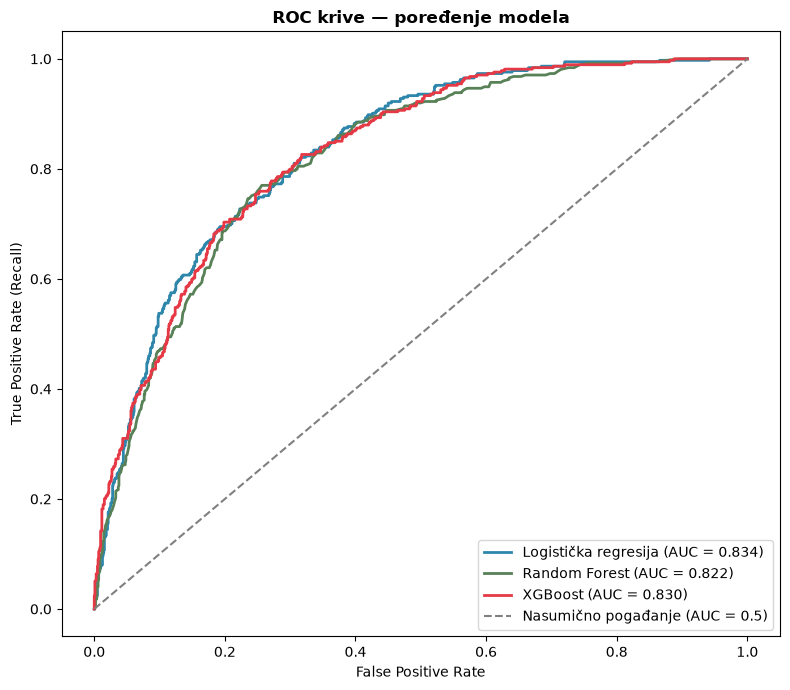

In [58]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

for naziv, y_prob, boja in [
    ("Logistička regresija", y_prob_logreg, "#2E86AB"),
    ("Random Forest", y_prob_rf, "#588157"),
    ("XGBoost", y_prob_xgb, "#E63946"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{naziv} (AUC = {auc_val:.3f})", color=boja, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Nasumično pogađanje (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC krive — poređenje modela", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/07_roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Zaključak

U ovom notebook-u izgradili smo i evaluirali tri modela za predviđanje
odlaska korisnika: Logističku regresiju, Random Forest i XGBoost.

Sva tri modela su uspešno naučena na trening skupu i evaluirana na
nezavisnom test skupu pomoću Accuracy, Precision, Recall, F1-score i
ROC-AUC metrike.

Rezultati pokazuju da:
- Random Forest ostvaruje najveću Accuracy vrednost,
- logistička regresija ostvaruje najveći Recall i ROC-AUC,
- XGBoost ostvaruje najbolji F1-score.

Pošto je kod predviđanja churn-a važno pravovremeno prepoznati korisnike
koji će napustiti kompaniju, Recall predstavlja posebno važnu metriku.
Na osnovu tog kriterijuma, logistička regresija se izdvaja kao
najpogodniji model među testiranim modelima, dok XGBoost predstavlja
konkurentnu alternativu sa najboljim F1-score rezultatom.

Dobijeni modeli predstavljaju osnovu za dalju optimizaciju i eventualno
podešavanje hiperparametara.

**Dodatne provere (sekcije 6-9):** analiza važnosti atributa potvrdila je da novi feature `ActiveServices` nosi stvarnu prediktivnu vrednost. Cross-validacija je potvrdila da rezultati nisu slučajni (mala standardna devijacija kroz 5 foldova). Podešavanje hiperparametara je sprovedeno sistematski putem Grid/Randomized Search-a za dva najbolja modela. ROC krive vizuelno potvrđuju da sva tri modela značajno nadmašuju nasumično pogađanje (AUC > 0.5).